<a href="https://colab.research.google.com/github/mallakhasan123/KHCC-AidConnect-GP-2026/blob/main/03_EDA_Hypothesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount your drive for this notebook session
from google.colab import drive
drive.mount('/content/drive')

# Point to the CSV file inside your Google Drive folder
path = '/content/drive/MyDrive/KHCC AidConnect GP 2026/patients_clean.csv'

# Load the clean patients CSV data
patients = pd.read_csv(path)

Mounted at /content/drive


/tmp/ipykernel_2639/701475886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Cancer Type', data=patients, order=order, palette='Blues_r')


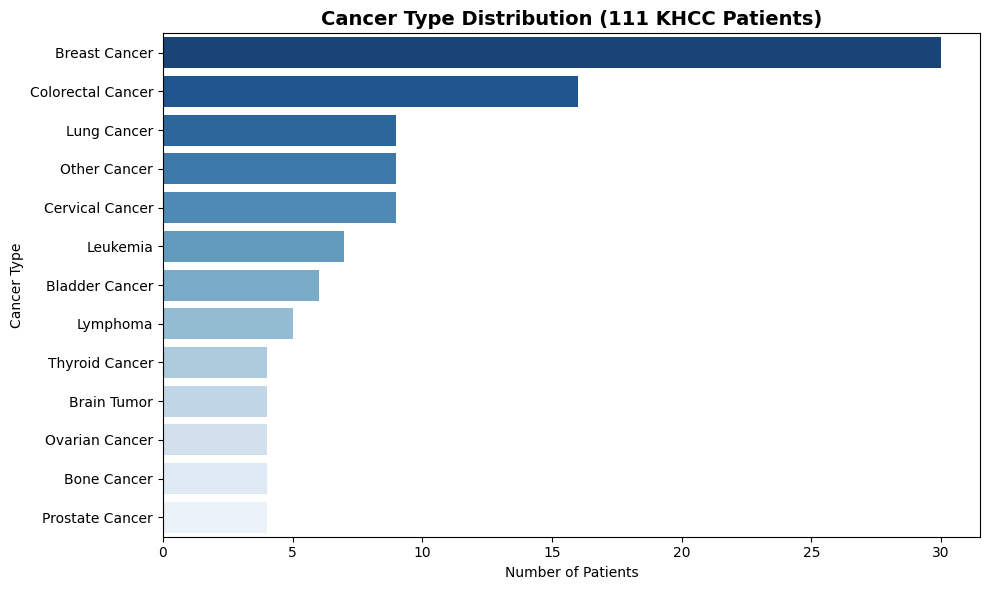

In [2]:
plt.figure(figsize=(10, 6))
order = patients['Cancer Type'].value_counts().index
sns.countplot(y='Cancer Type', data=patients, order=order, palette='Blues_r')
plt.title('Cancer Type Distribution (111 KHCC Patients)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart1_cancer_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

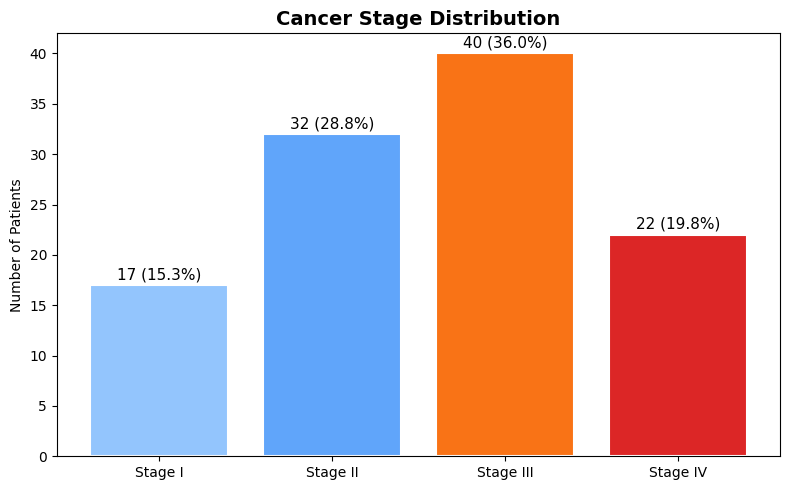

In [3]:
stage_order = ['Stage I','Stage II','Stage III','Stage IV']
stage_counts = patients['Cancer Stage'].value_counts()[stage_order]

plt.figure(figsize=(8, 5))
colors = ['#93C5FD','#60A5FA','#F97316','#DC2626']
bars = plt.bar(stage_order, stage_counts.values, color=colors,
               edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, stage_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{count} ({count/len(patients)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

plt.title('Cancer Stage Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart2_stage.png',
            dpi=150, bbox_inches='tight')
plt.show()

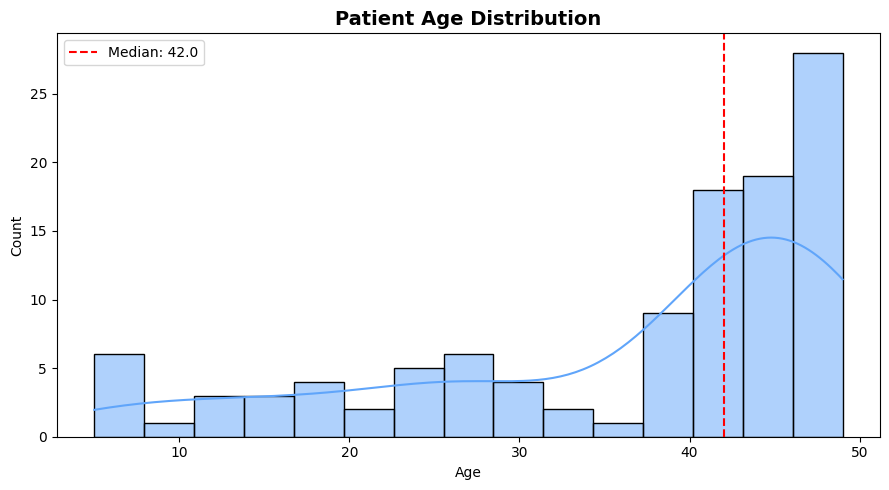

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(patients['Age'], bins=15, kde=True, color='#60A5FA')
plt.axvline(patients['Age'].median(), color='red',
            linestyle='--', label=f"Median: {patients['Age'].median()}")
plt.title('Patient Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart3_age.png',
            dpi=150, bbox_inches='tight')
plt.show()

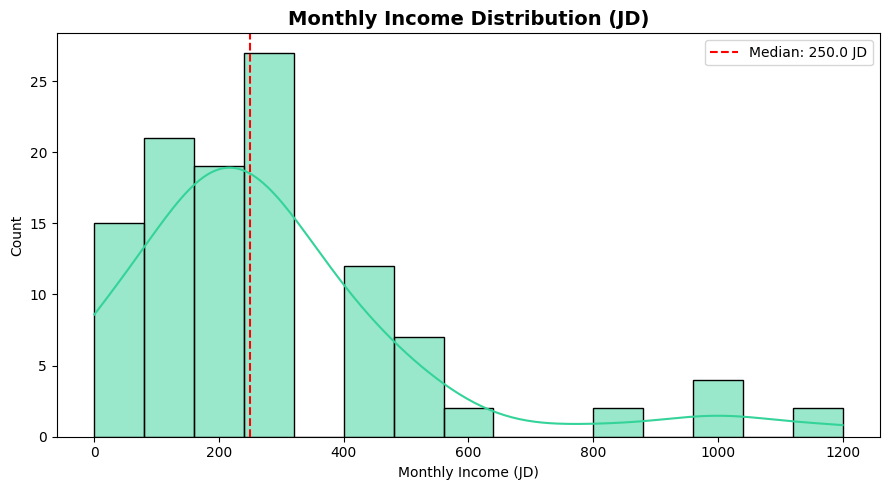

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(patients['Monthly Income JD'], bins=15, kde=True,
             color='#34D399')
plt.axvline(patients['Monthly Income JD'].median(), color='red',
            linestyle='--',
            label=f"Median: {patients['Monthly Income JD'].median()} JD")
plt.title('Monthly Income Distribution (JD)',
          fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income (JD)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart4_income.png',
            dpi=150, bbox_inches='tight')
plt.show()

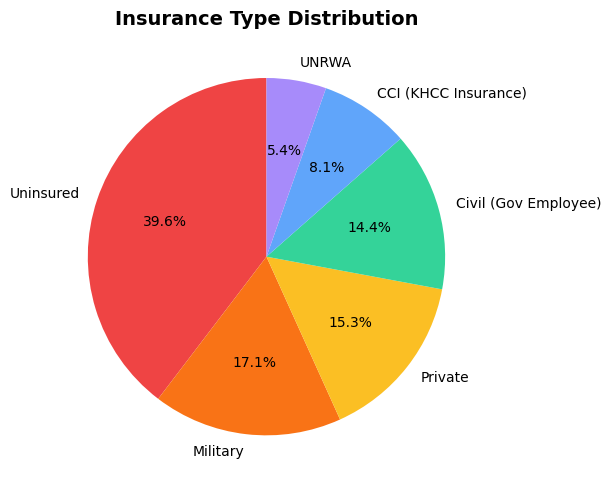

In [6]:
plt.figure(figsize=(8, 5))
ins = patients['Insurance Type'].value_counts()
colors_ins = ['#EF4444','#F97316','#FBBF24','#34D399','#60A5FA','#A78BFA']
plt.pie(ins.values, labels=ins.index, autopct='%1.1f%%',
        colors=colors_ins, startangle=90)
plt.title('Insurance Type Distribution',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart5_insurance.png',
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2639/1844128774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancer Stage', y='Need Score 0 to 1',


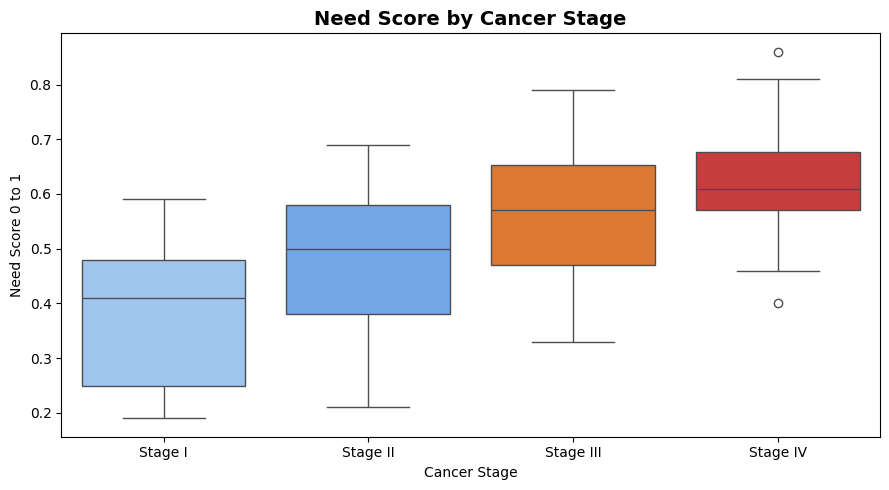

In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Cancer Stage', y='Need Score 0 to 1',
            data=patients,
            order=['Stage I','Stage II','Stage III','Stage IV'],
            palette=['#93C5FD','#60A5FA','#F97316','#DC2626'])
plt.title('Need Score by Cancer Stage',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart6_need_stage.png',
            dpi=150, bbox_inches='tight')
plt.show()

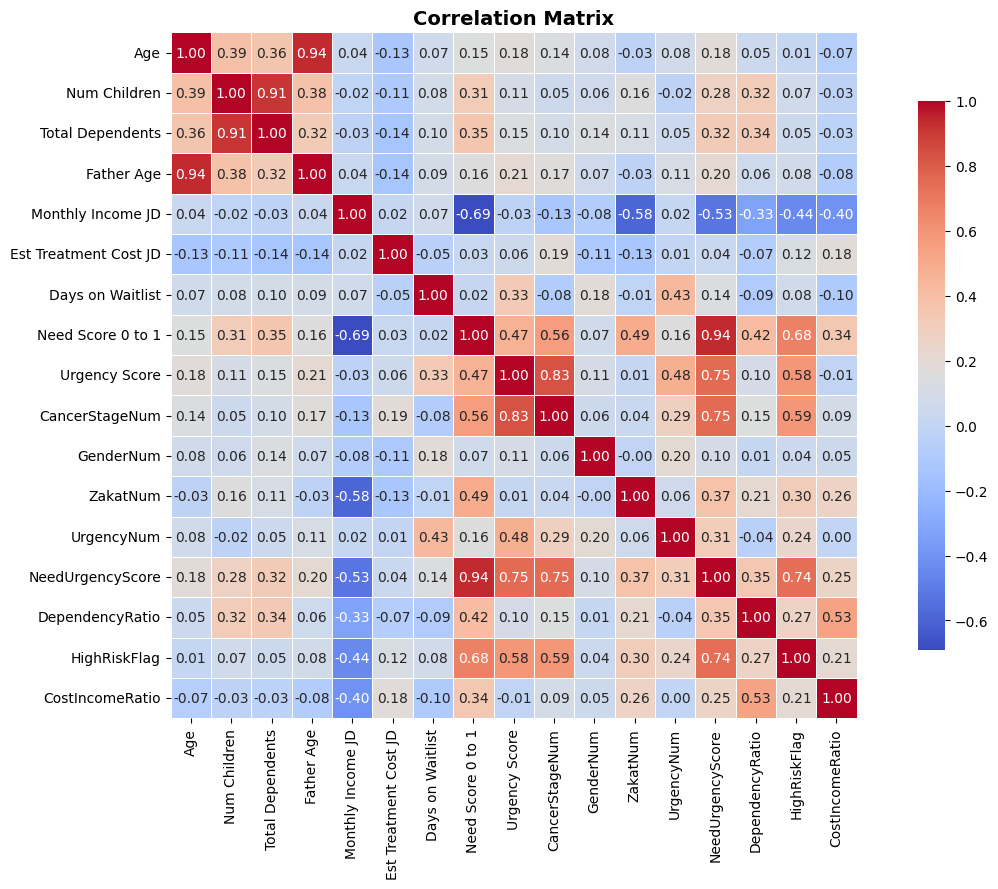

In [8]:
num_cols = patients.select_dtypes(include='number').columns.tolist()
corr = patients[num_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\chart7_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

H₀: No difference in Need Score between early and late stage
T-statistic : 5.6443
P-value     : 0.0000
Decision    : Reject H₀ ✓


/tmp/ipykernel_2639/1112338115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cancer Stage', y='Need Score 0 to 1', data=patients,


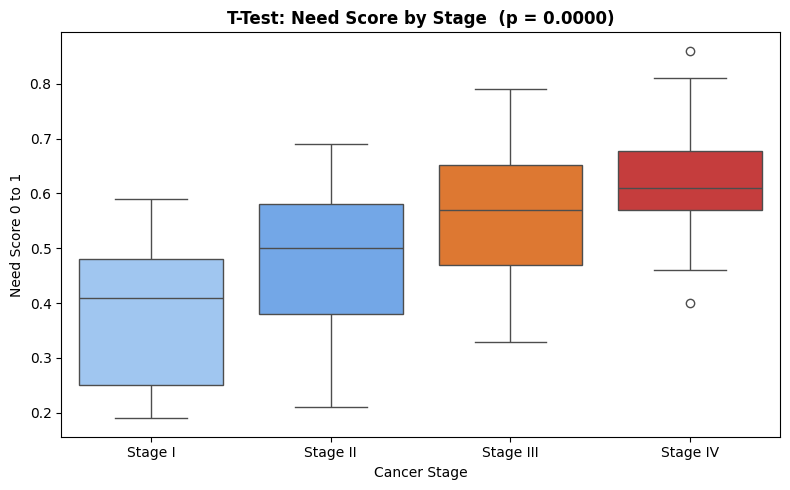

In [9]:
from scipy.stats import ttest_ind

early = patients[patients['CancerStageNum'] <= 2]['Need Score 0 to 1']
late  = patients[patients['CancerStageNum'] >= 3]['Need Score 0 to 1']

t_stat, p_val = ttest_ind(late, early)
print("H₀: No difference in Need Score between early and late stage")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4f}")
print(f"Decision    : {'Reject H₀ ✓' if p_val < 0.05 else 'Fail to reject H₀'}")

plt.figure(figsize=(8, 5))
sns.boxplot(x='Cancer Stage', y='Need Score 0 to 1', data=patients,
            order=['Stage I','Stage II','Stage III','Stage IV'],
            palette=['#93C5FD','#60A5FA','#F97316','#DC2626'])
plt.title(f'T-Test: Need Score by Stage  (p = {p_val:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\test1_ttest.png',
            dpi=150, bbox_inches='tight')
plt.show()

H₀: Zakat eligibility is independent of urgency status
Chi-square  : 0.0857
P-value     : 0.7697
Decision    : Fail to reject H₀


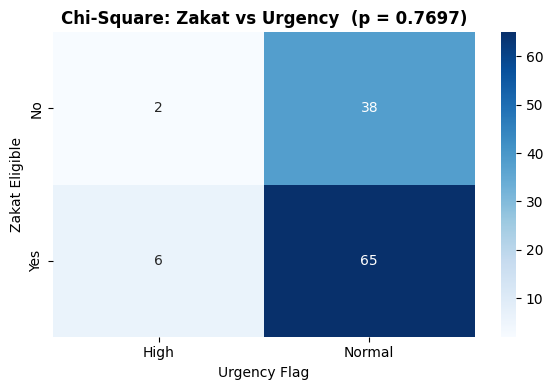

In [10]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(patients['Zakat Eligible'], patients['Urgency Flag'])
chi2, p, dof, expected = chi2_contingency(ct)
print("H₀: Zakat eligibility is independent of urgency status")
print(f"Chi-square  : {chi2:.4f}")
print(f"P-value     : {p:.4f}")
print(f"Decision    : {'Reject H₀ ✓' if p < 0.05 else 'Fail to reject H₀'}")

plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title(f'Chi-Square: Zakat vs Urgency  (p = {p:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\test2_chisquare.png',
            dpi=150, bbox_inches='tight')
plt.show()

H₀: No correlation between monthly income and need score
Pearson r   : -0.6900
P-value     : 0.0000
Decision    : Reject H₀ ✓


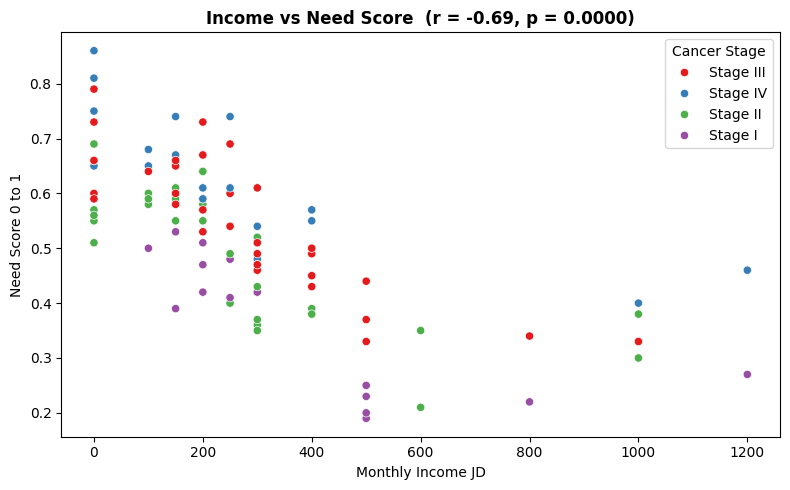

In [11]:
from scipy.stats import pearsonr

r, p = pearsonr(patients['Monthly Income JD'],
                patients['Need Score 0 to 1'])
print("H₀: No correlation between monthly income and need score")
print(f"Pearson r   : {r:.4f}")
print(f"P-value     : {p:.4f}")
print(f"Decision    : {'Reject H₀ ✓' if p < 0.05 else 'Fail to reject H₀'}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Monthly Income JD', y='Need Score 0 to 1',
                hue='Cancer Stage', data=patients, palette='Set1')
plt.title(f'Income vs Need Score  (r = {r:.2f}, p = {p:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\test3_pearson.png',
            dpi=150, bbox_inches='tight')
plt.show()